# Laboratorio 7: Audio y Transcripción con Whisper

### Bloque: Adquisición de Corpus

**Objetivo:** Incorporar fuentes audiovisuales al repertorio de adquisición de corpus textual, completando el pipeline webscraping -> transcripcion -> texto procesable.

**Herramientas principales:** `yt-dlp`, `openai-whisper`, `faster-whisper`
**Tiempo estimado:** 2 horas de laboratorio


## Encuadre conceptual - Por que extraer texto de audio

En la práctica profesional de PLN, una proporcion significativa de los corpus no proviene de paginas HTML ni de documentos ya escritos, sino de fuentes orales: entrevistas, podcasts, conferencias, sesiones legislativas, clases grabadas y testimonios. Si un pipeline de NLP solo contempla texto escrito extraido de la web, deja afuera una porcion importante del lenguaje socialmente producido. La transcripcion automatica de voz, conocida como ASR (`Automatic Speech Recognition`), resolvio buena parte de ese problema en los ultimos años gracias a modelos como Whisper, que permiten convertir audio en texto con muy buen desempeño tambien en español.

Ahora bien, la conversion audio -> texto no fue una operacion neutra. Cada sistema tuvo que decidir cómo puntuar, cómo segmentar, qué hacer con las hesitaciones, como representar repeticiones, silencios, cortes de habla y ruido de fondo, e incluso si convino o no identificar hablantes. Esas decisiones afectaron el texto resultante y, por lo tanto, condicionan cualquier analisis linguistico posterior. En otras palabras: cuando transcribis, no solo cambias de soporte; tambien producis una version del discurso que despues va a circular como dato.


## Más alla de YouTube: un mapa de fuentes de audio transcribibles

| Tipo de fuente | Ejemplos concretos | Método de obtencion |
|---|---|---|
| Plataformas de video | YouTube, Vimeo, Twitch, TikTok, Instagram Reels, Facebook Video | `yt-dlp` |
| Podcasts y audio | Spotify, iVoox, SoundCloud, feeds RSS con `.mp3` directo | `yt-dlp`, `spotdl`, descarga directa |
| Repositorios institucionales | Archivos orales de bibliotecas nacionales, archivos universitarios, proyectos de historia oral como StoryCorps o Archivo de la Palabra | descarga directa o scraping |
| Medios de comunicacion | Radios online con archivo, sesiones legislativas transmitidas, conferencias de prensa | `yt-dlp` o descarga directa |
| Conferencias y educacion | Charlas TED, grabaciones de Zoom, Meet o Teams, MOOCs | APIs especificas, exportacion, `yt-dlp` |
| Mensajeria | Audios de WhatsApp (`.opus`), Telegram, Signal | exportacion manual del chat |
| Fuentes de campo propias | Entrevistas grabadas, registros etnograficos, testimonios orales | grabacion directa |

La herramienta de transcripcion puede ser siempre la misma. Whisper recibe audio y devuelve texto. Lo que varia, entonces, no es el corazon del pipeline sino el modo en que obtuviste el archivo de audio. Esa distincion unifica el problema tecnico: distintas fuentes, un mismo proceso de conversion a corpus textual.


## Consideraciones eticas y legales

Trabajar con audio y video exige una atencion especial a derechos de autor, terminos de servicio y proteccion de datos. No es lo mismo usar un material con fines educativos o de investigacion que redistribuirlo comercialmente o volver a publicarlo. Cuando se trabaja con entrevistas, testimonios o registros orales propios, el consentimiento informado es un requisito metodologico y etico, no un detalle administrativo. Ademas, la transcripcion puede convertir un audio en un dato facilmente indexable, lo que aumenta la exposicion de informacion personal identificable. Para las actividades del curso, conviene priorizar materiales de licencia abierta, Creative Commons o con consentimiento explicito para uso pedagogico.


## Preparacion del entorno de trabajo

En este laboratorio vamos a combinar tres piezas. `yt-dlp` es el fork mantenido de `youtube-dl` y soporta cientos de sitios, por lo que sirve como herramienta general de descarga y extracción de audio. `openai-whisper` es la implementacion open-source del modelo Whisper y corre de forma local, con muy buen rendimiento en español incluso sin GPU si elegis un tamano de modelo adecuado. Como alternativa mas liviana aparece `faster-whisper`, una implementacion optimizada para CPU y GPU. La tercera pieza es `ffmpeg`, una dependencia clave para convertir formatos y para que `yt-dlp` pueda extraer audio de manera consistente.


In [1]:
# Instalacion de dependencias
# NOTA: ejecutar una sola vez. Si ya estan instaladas, podes saltear esta celda.
# Si ffmpeg no esta instalado a nivel sistema:
# - Ubuntu/Debian: sudo apt install ffmpeg
# - macOS con Homebrew: brew install ffmpeg
# - Windows con Chocolatey: choco install ffmpeg
# - Windows con winget: winget install Gyan.FFmpeg
# IMPORTANTE: `ffmpeg-python` no instala el ejecutable `ffmpeg`; este cuaderno usa el binario del sistema.
# Opcional: si `ffmpeg` no queda en PATH, podes definir `FFMPEG_PATH` con la ruta completa al ejecutable.

import os
import re
import shutil
import subprocess
import sys

_MODELOS_WHISPER = {}

def preparar_ffmpeg() -> tuple[str, str, str]:
    ruta_ffmpeg = os.environ.get("FFMPEG_PATH") or shutil.which("ffmpeg")
    if not ruta_ffmpeg or not os.path.exists(ruta_ffmpeg):
        raise FileNotFoundError(
            "No se encontro `ffmpeg` en PATH ni mediante la variable de entorno `FFMPEG_PATH`. "
            "Instala FFmpeg a nivel sistema y reinicia el kernel de Jupyter. "
            "En Windows podes usar: `choco install ffmpeg` o `winget install Gyan.FFmpeg`."
        )

    ffmpeg_dir = os.path.dirname(ruta_ffmpeg)
    candidatos_ffprobe = [
        os.environ.get("FFPROBE_PATH"),
        shutil.which("ffprobe"),
        os.path.join(ffmpeg_dir, "ffprobe"),
        os.path.join(ffmpeg_dir, "ffprobe.exe"),
    ]
    ruta_ffprobe = next((ruta for ruta in candidatos_ffprobe if ruta and os.path.exists(ruta)), None)
    if ruta_ffprobe is None:
        raise FileNotFoundError("Se encontro `ffmpeg` pero no `ffprobe` en PATH ni en la misma carpeta.")

    if ffmpeg_dir not in os.environ.get("PATH", ""):
        os.environ["PATH"] = ffmpeg_dir + os.pathsep + os.environ.get("PATH", "")

    return ruta_ffmpeg, ffmpeg_dir, ruta_ffprobe

def sanitizar_nombre_archivo(ruta_o_nombre: str, max_len: int = 80) -> str:
    nombre = os.path.splitext(os.path.basename(ruta_o_nombre))[0]
    invalidos = set('<>:/\\|?*') | {chr(34)}
    nombre = ''.join('_' if caracter in invalidos or ord(caracter) < 32 else caracter for caracter in nombre)
    nombre = re.sub(r'\s+', ' ', nombre).strip().rstrip('. ')
    return (nombre[:max_len] or 'transcripcion').strip()

subprocess.run([sys.executable, "-m", "pip", "install", "yt-dlp"], check=True)
subprocess.run([sys.executable, "-m", "pip", "install", "openai-whisper"], check=True)
# Alternativa liviana:
# subprocess.run([sys.executable, "-m", "pip", "install", "faster-whisper"], check=True)

ruta_ffmpeg, ffmpeg_dir, ruta_ffprobe = preparar_ffmpeg()
verificacion_ffmpeg = subprocess.run([ruta_ffmpeg, "-version"], capture_output=True, text=True, check=True)
print(verificacion_ffmpeg.stdout.splitlines()[0])
print(f"ffprobe detectado en: {ruta_ffprobe}")


ffmpeg version 8.1-full_build-www.gyan.dev Copyright (c) 2000-2026 the FFmpeg developers
ffprobe detectado en: C:\Users\domin\AppData\Local\Microsoft\WinGet\Packages\Gyan.FFmpeg_Microsoft.Winget.Source_8wekyb3d8bbwe\ffmpeg-8.1-full_build\bin\ffprobe.EXE


## Paso 1 - Descarga de audio desde YouTube

`yt-dlp` permite descargar solo la pista de audio, sin conservar el video completo, usando `--extract-audio`. Ademas, podes elegir formato de salida y nivel de calidad. Para el ejemplo vamos a usar una charla en espanol disponible en YouTube. Si queres reutilizar el material fuera del aula, verifica antes la licencia de publicacion y las condiciones de uso del canal.

**URL de ejemplo:** `https://www.youtube.com/watch?v=yX2tPSjBoeU`


In [2]:
import os
import subprocess
import sys

# URL de ejemplo en espanol. Antes de redistribuir, verifica licencia y condiciones de uso.
video_url = "https://www.youtube.com/watch?v=yX2tPSjBoeU"

output_dir = "audios"
os.makedirs(output_dir, exist_ok=True)

_, ffmpeg_dir, _ = preparar_ffmpeg()

subprocess.run(
    [
        sys.executable,
        "-m",
        "yt_dlp",
        "--ffmpeg-location", ffmpeg_dir,
        "--extract-audio",
        "--audio-format", "mp3",
        "--audio-quality", "0",
        "--output", f"{output_dir}/%(title)s.%(ext)s",
        video_url,
    ],
    check=True,
)

print("Audio descargado correctamente.")
print("Archivos en el directorio:")
for archivo in sorted(os.listdir(output_dir)):
    print(f"  - {archivo}")


Audio descargado correctamente.
Archivos en el directorio:
  - ¿Cuál es el motor de la ciencia？ ｜ Mario Ponce ｜ TEDxLINTAC Youth.mp3


## Alternativa - `yt-dlp` como biblioteca Python

Aunque mucha gente usa `yt-dlp` desde terminal, tambien podes importarlo como modulo de Python. Ese enfoque resulta util cuando queres integrar la descarga dentro de un pipeline mas grande sin depender de `subprocess`. Conviene conocer ambos estilos porque en proyectos reales aparecen los dos.


In [3]:
import yt_dlp

url = "https://www.youtube.com/watch?v=yX2tPSjBoeU"

_, ffmpeg_dir, _ = preparar_ffmpeg()

ydl_opts = {
    "format": "bestaudio/best",
    "noplaylist": True,
    "ffmpeg_location": ffmpeg_dir,
    "postprocessors": [
        {
            "key": "FFmpegExtractAudio",
            "preferredcodec": "mp3",
            "preferredquality": "192",
        }
    ],
    "outtmpl": "audios/%(title)s.%(ext)s",
}

with yt_dlp.YoutubeDL(ydl_opts) as ydl:
    info = ydl.extract_info(url, download=True)
    print(f"Titulo: {info['title']}")
    print(f"Duracion: {info['duration']} segundos")
    print(f"Canal: {info['uploader']}")


[youtube] Extracting URL: https://www.youtube.com/watch?v=yX2tPSjBoeU
[youtube] yX2tPSjBoeU: Downloading webpage


[youtube] yX2tPSjBoeU: Downloading android vr player API JSON
[info] yX2tPSjBoeU: Downloading 1 format(s): 251
[download] Destination: audios\¿Cuál es el motor de la ciencia？ ｜ Mario Ponce ｜ TEDxLINTAC Youth.webm
[download] 100% of   13.47MiB in 00:00:00 at 19.10MiB/s    
[ExtractAudio] Destination: audios\¿Cuál es el motor de la ciencia？ ｜ Mario Ponce ｜ TEDxLINTAC Youth.mp3
Deleting original file audios\¿Cuál es el motor de la ciencia？ ｜ Mario Ponce ｜ TEDxLINTAC Youth.webm (pass -k to keep)
Titulo: ¿Cuál es el motor de la ciencia? | Mario Ponce | TEDxLINTAC Youth
Duracion: 1173 segundos
Canal: TEDx Talks


## Paso 2 - Transcripcion con Whisper

Whisper es un modelo transformer encoder-decoder entrenado sobre un volumen masivo de audio multilingue. Viene en varios tamanos: `tiny`, `base`, `small`, `medium` y `large`. A mayor tamano, mejor calidad potencial, pero tambien mayor demanda de RAM y tiempo de procesamiento. Para espanol, `small` y `medium` suelen ofrecer muy buenos resultados. Si trabajas en una notebook o PC sin GPU, conviene empezar con `base` o `small`. Con GPU, `medium` o `large` pueden justificar el costo computacional.

Whisper devuelve, ademas del texto completo, una lista de segmentos con timestamps y el idioma detectado. Eso es importante porque te permite decidir si queres solo texto plano o si necesitas preservar la estructura temporal del discurso.

| Modelo | Parametros aproximados | RAM aproximada | Velocidad relativa |
|---|---:|---:|---|
| `tiny` | 39 M | ~1 GB | Muy alta |
| `base` | 74 M | ~1 GB | Alta |
| `small` | 244 M | ~2 GB | Media |
| `medium` | 769 M | ~5 GB | Baja |
| `large` / `large-v3` | 1550 M | ~10 GB | Muy baja |


In [4]:
import os
import whisper

preparar_ffmpeg()
if "small" not in _MODELOS_WHISPER:
    _MODELOS_WHISPER["small"] = whisper.load_model("small")
modelo = _MODELOS_WHISPER["small"]

archivos_audio = [os.path.join("audios", archivo) for archivo in os.listdir("audios") if archivo.lower().endswith(".mp3")]
if not archivos_audio:
    raise FileNotFoundError("No se encontro ningun audio en 'audios/'. Ejecuta antes la celda de descarga.")

audio_path = os.path.abspath(max(archivos_audio, key=os.path.getmtime))
print(f"Archivo seleccionado: {audio_path}")

resultado = modelo.transcribe(audio_path, language="es", verbose=True, fp16=False)

print("=" * 60)
print("TRANSCRIPCION COMPLETA")
print("=" * 60)
print(resultado["text"])


100%|███████████████████████████████████████| 461M/461M [00:15<00:00, 30.9MiB/s]


Archivo seleccionado: c:\tpIntegrador\dominguez-micaela-belen-pln-1c-2026\002\002-PRA\audios\¿Cuál es el motor de la ciencia？ ｜ Mario Ponce ｜ TEDxLINTAC Youth.mp3
[00:00.000 --> 00:18.320]  ¿Qué mueve a la ciencia? ¿Cuál es el motor de la ciencia?
[00:18.320 --> 00:25.280]  ¿Curiosidad? ¿Busqué el bien común? Progreso, piénselo, piénselo ustedes.
[00:25.280 --> 00:29.920]  Vamos a tratar de recorrer un poquito esa pregunta durante esta charla, pero antes
[00:29.920 --> 00:36.040]  de ir directo hacia ella quiero que participemos un poco y para eso los quiero
[00:36.040 --> 00:41.600]  invitar a quien quiere ser millonario. Yo soy matemático pero me gusta la
[00:41.600 --> 00:46.840]  astronomía. Quiero preguntarles cuál es el personaje más importante de la
[00:46.840 --> 00:51.280]  historia de la astronomía y les traje algunos candidatos,
[00:51.280 --> 00:58.560]  Nicolaco Pernico, Tico Brae, Johan Schaepler y Sack Newton. A ver, participemos
[00:58.560 --> 01:04.080]  muy rápido, ¿q

In [5]:
print(f"Idioma detectado: {resultado['language']}")
print(f"Total de segmentos: {len(resultado['segments'])}")
print()

for segmento in resultado["segments"][:10]:
    inicio = segmento["start"]
    fin = segmento["end"]
    texto = segmento["text"].strip()
    print(f"[{inicio:07.2f} -> {fin:07.2f}] {texto}")


Idioma detectado: es
Total de segmentos: 219

[0000.00 -> 0018.32] ¿Qué mueve a la ciencia? ¿Cuál es el motor de la ciencia?
[0018.32 -> 0025.28] ¿Curiosidad? ¿Busqué el bien común? Progreso, piénselo, piénselo ustedes.
[0025.28 -> 0029.92] Vamos a tratar de recorrer un poquito esa pregunta durante esta charla, pero antes
[0029.92 -> 0036.04] de ir directo hacia ella quiero que participemos un poco y para eso los quiero
[0036.04 -> 0041.60] invitar a quien quiere ser millonario. Yo soy matemático pero me gusta la
[0041.60 -> 0046.84] astronomía. Quiero preguntarles cuál es el personaje más importante de la
[0046.84 -> 0051.28] historia de la astronomía y les traje algunos candidatos,
[0051.28 -> 0058.56] Nicolaco Pernico, Tico Brae, Johan Schaepler y Sack Newton. A ver, participemos
[0058.56 -> 0064.08] muy rápido, ¿quién levanta la mano por la A? Nicolaco Pernico. Muy bien, vamos a
[0064.08 -> 0067.16] ir anotando aquí las respuestas en el común del público.


## Paso 3 - Exportacion y persistencia del corpus

Una vez transcripto el audio, el texto se guarda para uso posterior dentro del pipeline de PLN. El formato `.txt` es el mas directo si queres pasar rapido a una etapa de procesamiento linguistico. El formato `.json`, en cambio, preserva metadatos y timestamps, por lo que resulta especialmente util si despues queres analizar estructura temporal, comparar segmentos o volver al audio original.


In [6]:
import json
import os

output_dir = "transcripciones"
os.makedirs(output_dir, exist_ok=True)

nombre_base = sanitizar_nombre_archivo(audio_path)
fuente_actual = video_url if "video_url" in globals() else None

ruta_txt = os.path.join(output_dir, f"{nombre_base}.txt")
with open(ruta_txt, "w", encoding="utf-8") as archivo_txt:
    archivo_txt.write(resultado["text"])
print(f"Texto plano guardado en: {ruta_txt}")

ruta_json = os.path.join(output_dir, f"{nombre_base}.json")
datos = {
    "fuente": fuente_actual,
    "idioma_detectado": resultado["language"],
    "texto_completo": resultado["text"],
    "segmentos": [
        {
            "inicio": segmento["start"],
            "fin": segmento["end"],
            "texto": segmento["text"].strip(),
        }
        for segmento in resultado["segments"]
    ],
}
with open(ruta_json, "w", encoding="utf-8") as archivo_json:
    json.dump(datos, archivo_json, ensure_ascii=False, indent=2)
print(f"JSON con segmentos guardado en: {ruta_json}")


Texto plano guardado en: transcripciones\¿Cuál es el motor de la ciencia？ ｜ Mario Ponce ｜ TEDxLINTAC Youth.txt
JSON con segmentos guardado en: transcripciones\¿Cuál es el motor de la ciencia？ ｜ Mario Ponce ｜ TEDxLINTAC Youth.json


## Alternativa liviana - `faster-whisper`

`faster-whisper` usa CTranslate2, una implementacion optimizada que suele ser mas rapida y consumir menos RAM que `openai-whisper`. La API cambia un poco, pero el resultado conceptual es equivalente: audio de entrada, segmentos con timestamps y texto final. Para maquinas con recursos limitados, esta opcion suele ser la mas conveniente.


In [7]:
# Alternativa: faster-whisper (mas rapido, menos RAM)
# Instalar si hace falta:
# !pip install faster-whisper

import os
from faster_whisper import WhisperModel

preparar_ffmpeg()
audio_path = os.path.abspath(audio_path)
modelo_fw = WhisperModel("small", device="cpu", compute_type="int8")

segmentos, info = modelo_fw.transcribe(audio_path, language="es")

print(f"Idioma detectado: {info.language} (probabilidad: {info.language_probability:.2%})")
print()

texto_completo = []
for segmento in segmentos:
    print(f"[{segmento.start:07.2f} -> {segmento.end:07.2f}] {segmento.text.strip()}")
    texto_completo.append(segmento.text.strip())

transcripcion = " ".join(texto_completo)
print("\n" + "=" * 60)
print(transcripcion)


c:\tpIntegrador\dominguez-micaela-belen-pln-1c-2026\venv\Lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\domin\.cache\huggingface\hub\models--Systran--faster-whisper-small. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


Idioma detectado: es (probabilidad: 100.00%)

[0000.00 -> 0019.00] ¿Qué mueve a la ciencia? ¿Cuál es el motor de la ciencia?
[0019.00 -> 0025.00] ¿Curiosidad? ¿Busqué el bien común? Progreso, piénselo, piénselo ustedes.
[0025.00 -> 0029.00] Vamos a tratar de recorrer un poquito esa pregunta durante esta charla,
[0029.00 -> 0033.00] pero antes de ir directo hacia ella, quiero que participemos un poco.
[0033.00 -> 0039.00] Y para eso, los quiero invitar a quien quiere ser millonario.
[0039.00 -> 0042.00] Yo soy matemático, pero me gusta la astronomía.
[0042.00 -> 0048.00] Quiero preguntarles cuál es el personaje más importante de la historia de la astronomía
[0048.00 -> 0051.00] y les traje algunos candidatos.
[0051.00 -> 0057.00] Nicolaco Pernico, Tico Brae, Johan Schaepler y Sack Newton.
[0057.00 -> 0059.00] A ver, participemos muy rápido.
[0059.00 -> 0063.00] ¿Quién levanta la mano por la A? Nicolaco Pernico. Muy bien.
[0063.00 -> 0067.00] Vamos a ir anotando aquí las respuestas en el

## Integrando todo: funcion reutilizable

Hasta aca trabajaste cada paso por separado. Ahora vamos a encapsular el flujo completo en una funcion que reciba una URL de YouTube y devuelva texto listo para procesar. Esta clase de integracion importa porque transforma una serie de pruebas manuales en un pipeline reutilizable para construir corpus de manera sistematica.


In [8]:
def youtube_a_texto(url: str, modelo_whisper: str = "small", idioma: str = "es", output_dir: str = "corpus") -> dict:
    # Pipeline completo: URL de YouTube -> audio -> transcripcion -> texto
    import json
    import os
    import re
    import shutil
    import whisper
    import yt_dlp

    os.makedirs(output_dir, exist_ok=True)

    if "preparar_ffmpeg" in globals():
        _, ffmpeg_dir, _ = preparar_ffmpeg()
    else:
        ruta_ffmpeg = os.environ.get("FFMPEG_PATH") or shutil.which("ffmpeg")
        if not ruta_ffmpeg or not os.path.exists(ruta_ffmpeg):
            raise FileNotFoundError("No se encontro ffmpeg para ejecutar el pipeline completo.")
        ffmpeg_dir = os.path.dirname(ruta_ffmpeg)
        if ffmpeg_dir not in os.environ.get("PATH", ""):
            os.environ["PATH"] = ffmpeg_dir + os.pathsep + os.environ.get("PATH", "")

    ydl_opts = {
        "format": "bestaudio/best",
        "noplaylist": True,
        "ffmpeg_location": ffmpeg_dir,
        "postprocessors": [
            {
                "key": "FFmpegExtractAudio",
                "preferredcodec": "mp3",
                "preferredquality": "192",
            }
        ],
        "outtmpl": f"{output_dir}/%(title)s.%(ext)s",
    }

    if "sanitizar_nombre_archivo" in globals():
        sanitizar = sanitizar_nombre_archivo
    else:
        def sanitizar(ruta_o_nombre: str, max_len: int = 80) -> str:
            nombre = os.path.splitext(os.path.basename(ruta_o_nombre))[0]
            invalidos = set('<>:/\\|?*') | {chr(34)}
            nombre = ''.join('_' if caracter in invalidos or ord(caracter) < 32 else caracter for caracter in nombre)
            nombre = re.sub(r'\s+', ' ', nombre).strip().rstrip('. ')
            return (nombre[:max_len] or 'transcripcion').strip()

    with yt_dlp.YoutubeDL(ydl_opts) as ydl:
        info = ydl.extract_info(url, download=True)
        titulo = info["title"]
        duracion = info["duration"]
        audio_generado = os.path.abspath(ydl.prepare_filename(info).rsplit(".", 1)[0] + ".mp3")

    print(f"Audio descargado: {titulo} ({duracion} segundos)")

    cache_modelos = globals().setdefault("_MODELOS_WHISPER", {})
    if modelo_whisper not in cache_modelos:
        cache_modelos[modelo_whisper] = whisper.load_model(modelo_whisper)
    modelo = cache_modelos[modelo_whisper]
    resultado_local = modelo.transcribe(audio_generado, language=idioma, fp16=False)
    print(f"Transcripcion completa: {len(resultado_local['segments'])} segmentos")

    nombre_base = sanitizar(audio_generado)
    ruta_txt = os.path.join(output_dir, f"{nombre_base}.txt")
    with open(ruta_txt, "w", encoding="utf-8") as archivo_txt:
        archivo_txt.write(resultado_local["text"])

    ruta_json = os.path.join(output_dir, f"{nombre_base}.json")
    with open(ruta_json, "w", encoding="utf-8") as archivo_json:
        json.dump(
            {
                "fuente": url,
                "titulo": titulo,
                "duracion_segundos": duracion,
                "idioma": resultado_local["language"],
                "texto": resultado_local["text"],
                "segmentos": [
                    {"inicio": segmento["start"], "fin": segmento["end"], "texto": segmento["text"].strip()}
                    for segmento in resultado_local["segments"]
                ],
            },
            archivo_json,
            ensure_ascii=False,
            indent=2,
        )

    return {
        "titulo": titulo,
        "duracion": duracion,
        "texto": resultado_local["text"],
        "segmentos": resultado_local["segments"],
        "archivos_generados": [audio_generado, ruta_txt, ruta_json],
    }


# Uso sugerido:
# corpus = youtube_a_texto("https://www.youtube.com/watch?v=yX2tPSjBoeU")
# print(corpus["texto"][:500])


## Descarga por lotes - Construir un corpus desde una lista de URLs

Cuando pasas de un solo archivo a varios videos, cambias de escala: ya no estas resolviendo una descarga puntual sino construyendo un corpus. En ese contexto aparecen problemas nuevos, como control de errores, consistencia de formatos, almacenamiento y trazabilidad. Procesar por lotes te permite convertir una lista de URLs en una coleccion de textos comparable y reutilizable.


In [9]:
urls = [
    "https://www.youtube.com/watch?v=yX2tPSjBoeU",
    "https://www.youtube.com/watch?v=ruepxLoEwoo",
    "https://www.youtube.com/watch?v=WqXr0AujesY",
]

resultados = []
errores = []

for indice, url in enumerate(urls, start=1):
    print("\n" + "=" * 60)
    print(f"Procesando {indice}/{len(urls)}: {url}")
    print("=" * 60)
    try:
        resultado_lote = youtube_a_texto(url, modelo_whisper="small")
        resultados.append(resultado_lote)
        print(f"OK: {resultado_lote['titulo']} - {len(resultado_lote['texto'])} caracteres")
    except Exception as error:
        errores.append({"url": url, "error": str(error)})
        print(f"ERROR: {error}")

print(f"\nResumen: {len(resultados)} exitosos, {len(errores)} errores")

corpus_total = "\n\n---\n\n".join(resultado_lote["texto"] for resultado_lote in resultados)
print(f"Corpus total: {len(corpus_total)} caracteres, ~{len(corpus_total.split())} palabras")



Procesando 1/3: https://www.youtube.com/watch?v=yX2tPSjBoeU
[youtube] Extracting URL: https://www.youtube.com/watch?v=yX2tPSjBoeU
[youtube] yX2tPSjBoeU: Downloading webpage


[youtube] yX2tPSjBoeU: Downloading android vr player API JSON
[info] yX2tPSjBoeU: Downloading 1 format(s): 251
[download] Destination: corpus\¿Cuál es el motor de la ciencia？ ｜ Mario Ponce ｜ TEDxLINTAC Youth.webm
[download] 100% of   13.47MiB in 00:00:00 at 16.27MiB/s    
[ExtractAudio] Destination: corpus\¿Cuál es el motor de la ciencia？ ｜ Mario Ponce ｜ TEDxLINTAC Youth.mp3
Deleting original file corpus\¿Cuál es el motor de la ciencia？ ｜ Mario Ponce ｜ TEDxLINTAC Youth.webm (pass -k to keep)
Audio descargado: ¿Cuál es el motor de la ciencia? | Mario Ponce | TEDxLINTAC Youth (1173 segundos)
Transcripcion completa: 219 segmentos
OK: ¿Cuál es el motor de la ciencia? | Mario Ponce | TEDxLINTAC Youth - 16322 caracteres

Procesando 2/3: https://www.youtube.com/watch?v=ruepxLoEwoo
[youtube] Extracting URL: https://www.youtube.com/watch?v=ruepxLoEwoo
[youtube] ruepxLoEwoo: Downloading webpage


[youtube] ruepxLoEwoo: Downloading android vr player API JSON
[info] ruepxLoEwoo: Downloading 1 format(s): 251
[download] Destination: corpus\La ciencia que te rodea y que no ves ｜ César Sobrero ｜ TEDxCONICETRosario.webm
[download] 100% of    9.77MiB in 00:00:01 at 5.97MiB/s     
[ExtractAudio] Destination: corpus\La ciencia que te rodea y que no ves ｜ César Sobrero ｜ TEDxCONICETRosario.mp3
Deleting original file corpus\La ciencia que te rodea y que no ves ｜ César Sobrero ｜ TEDxCONICETRosario.webm (pass -k to keep)
Audio descargado: La ciencia que te rodea y que no ves | César Sobrero | TEDxCONICETRosario (740 segundos)
Transcripcion completa: 149 segmentos
OK: La ciencia que te rodea y que no ves | César Sobrero | TEDxCONICETRosario - 10381 caracteres

Procesando 3/3: https://www.youtube.com/watch?v=WqXr0AujesY
[youtube] Extracting URL: https://www.youtube.com/watch?v=WqXr0AujesY
[youtube] WqXr0AujesY: Downloading webpage


[youtube] WqXr0AujesY: Downloading android vr player API JSON
[info] WqXr0AujesY: Downloading 1 format(s): 251
[download] Destination: corpus\Ciencia Clara： Rompiendo Barreras. ｜ Itzel Martinez ｜ TEDxPaseoUsumacintaAve.webm
[download] 100% of    5.78MiB in 00:00:00 at 6.44MiB/s   
[ExtractAudio] Destination: corpus\Ciencia Clara： Rompiendo Barreras. ｜ Itzel Martinez ｜ TEDxPaseoUsumacintaAve.mp3
Deleting original file corpus\Ciencia Clara： Rompiendo Barreras. ｜ Itzel Martinez ｜ TEDxPaseoUsumacintaAve.webm (pass -k to keep)
Audio descargado: Ciencia Clara: Rompiendo Barreras. | Itzel Martinez | TEDxPaseoUsumacintaAve (390 segundos)
Transcripcion completa: 119 segmentos
OK: Ciencia Clara: Rompiendo Barreras. | Itzel Martinez | TEDxPaseoUsumacintaAve - 4436 caracteres

Resumen: 3 exitosos, 0 errores
Corpus total: 31153 caracteres, ~5491 palabras


## Actividades

1. **Ejercicio basico.** Elegi un video de YouTube en espanol, preferentemente una conferencia, entrevista o clase abierta con licencia Creative Commons o con condiciones claras de uso educativo. Descargalo, transcribilo con Whisper y guarda el resultado en `.txt` y `.json`. Reporta duracion del audio, tiempo de transcripcion, cantidad de palabras obtenidas y una evaluacion subjetiva de la calidad del texto.

2. **Ejercicio intermedio.** Compara la transcripcion de Whisper con los subtitulos automaticos de YouTube para el mismo video. Para eso podes descargar subtitulos con `yt-dlp` usando `--write-auto-sub --sub-lang es`. Analiza que sistema produjo mejor texto, en que errores difirio cada uno y cual te parecio mas util como input para un pipeline de PLN.

3. **Ejercicio avanzado.** Construi un mini-corpus de al menos cinco videos de un mismo tema o canal. Procesalos en lote. Calcula estadisticas descriptivas del corpus: total de palabras, promedio por video, vocabulario unico y las 20 palabras mas frecuentes. Luego reflexiona si ese corpus te pareceria adecuado para ajustar un modelo de lenguaje o para analisis linguistico, y que preprocesamiento adicional necesitarias.


1 **Ejercicio basico**


PASO 1 : Elegi el video de una entrevista a una psiquiatra que se llama Marian Rojas Estape.

In [10]:
mi_video_url = "https://www.youtube.com/watch?v=0noAwrWY78U"

print("Video asignado a la variable")

Video asignado a la variable


PASO 2: Descargar, Transcribir y Guardar

In [11]:
print("Usamos la funcion youtube_a_texto para hacer todo el proceso")
mi_corpus = youtube_a_texto(mi_video_url, modelo_whisper="base")
print("\n¡Terminó el proceso!")
print("Acá tenés los primeros 500 caracteres de la transcripción:")
print("-" * 50)
print(mi_corpus["texto"][:500])
print("-" * 50)

Usamos la funcion youtube_a_texto para hacer todo el proceso
[youtube] Extracting URL: https://www.youtube.com/watch?v=0noAwrWY78U
[youtube] 0noAwrWY78U: Downloading webpage


[youtube] 0noAwrWY78U: Downloading android vr player API JSON
[info] 0noAwrWY78U: Downloading 1 format(s): 251
[download] Destination: corpus\El cerebro, nuestro mejor aliado contra el estrés. Marian Rojas-Estapé, psiquiatra y escritora.webm
[download] 100% of    4.83MiB in 00:00:00 at 11.18MiB/s  
[ExtractAudio] Destination: corpus\El cerebro, nuestro mejor aliado contra el estrés. Marian Rojas-Estapé, psiquiatra y escritora.mp3
Deleting original file corpus\El cerebro, nuestro mejor aliado contra el estrés. Marian Rojas-Estapé, psiquiatra y escritora.webm (pass -k to keep)
Audio descargado: El cerebro, nuestro mejor aliado contra el estrés. Marian Rojas-Estapé, psiquiatra y escritora (358 segundos)


100%|███████████████████████████████████████| 139M/139M [00:04<00:00, 33.0MiB/s]


Transcripcion completa: 55 segmentos

¡Terminó el proceso!
Acá tenés los primeros 500 caracteres de la transcripción:
--------------------------------------------------
 Con el ritmo de vida tan acelerado que llevamos, constantemente vivimos situaciones de estrés, de miedo, de frustración, cómo podemos prevenir y gestionar de maneras saludables de estos estados. Yo lo de unas cosas que más recomiendo a todo el mundo, a jóvenes, estudiantes, a más mayores, a gente adulta, este es donde estés, trabajes en lo que trabajes, es que tengas unas nociones básicas de cómo funcionas tú, cómo ser individual y cómo funciona la mente humana y el organismo humano en general.
--------------------------------------------------


PASO 3: Reporte

In [13]:
cantidad_palabras = len(mi_corpus["texto"].split())
duracion = mi_corpus["duracion"]
print("REPORTE DEL EJERCICIO BÁSICO")
print(f" Título del video: {mi_corpus['titulo']}")
print(f" Duración del audio: {duracion} segundos (aprox {duracion//60} minutos)")
print(f" Cantidad de palabras obtenidas: {cantidad_palabras} palabras")
print(" Tiempo de transcripción: 1.28")
print("\n Evaluación subjetiva de la calidad:")
print("La calidad del texto es muy precisa respecto a las palabras habladas, ")
print("pero carece de signos de puntuación tradicionales (puntos y comas), ")
print("lo cual es una característica esperable de los modelos ASR como Whisper ")
print("al procesar el flujo continuo de la oralidad.")

REPORTE DEL EJERCICIO BÁSICO
 Título del video: El cerebro, nuestro mejor aliado contra el estrés. Marian Rojas-Estapé, psiquiatra y escritora
 Duración del audio: 358 segundos (aprox 5 minutos)
 Cantidad de palabras obtenidas: 1076 palabras
 Tiempo de transcripción: 1.28

 Evaluación subjetiva de la calidad:
La calidad del texto es muy precisa respecto a las palabras habladas, 
pero carece de signos de puntuación tradicionales (puntos y comas), 
lo cual es una característica esperable de los modelos ASR como Whisper 
al procesar el flujo continuo de la oralidad.


**Ejercicio intermedio**

In [14]:
mi_video_url = "https://www.youtube.com/watch?v=0noAwrWY78U"

opciones = {
    'skip_download': True,       # Que no descargue el video
    'writeautomaticsub': True,   # Que baje los subtítulos generados por YT
    'subtitleslangs': ['es'],    # Que busque los que están en español
    'outtmpl': 'corpus/subtitulos_youtube.%(ext)s' # Nombre del archivo
}

print("Descargando los subtítulos de YouTube...")
with yt_dlp.YoutubeDL(opciones) as ydl:
    ydl.download([mi_video_url])

print("\n¡Descarga lista!")

Descargando los subtítulos de YouTube...
[youtube] Extracting URL: https://www.youtube.com/watch?v=0noAwrWY78U
[youtube] 0noAwrWY78U: Downloading webpage


[youtube] 0noAwrWY78U: Downloading android vr player API JSON
[info] 0noAwrWY78U: Downloading subtitles: es
[info] 0noAwrWY78U: Downloading 1 format(s): 399+251
[info] Writing video subtitles to: corpus\subtitulos_youtube.es.vtt


[download] Destination: corpus\subtitulos_youtube.es.vtt
[download] 100% of   54.04KiB in 00:00:00 at 445.34KiB/s

¡Descarga lista!


**Analisis comparativo**


In [15]:
import os

#1. Usamos la traduccion del video
texto_whisper = mi_corpus["texto"]

# 2. Leemos el archivo de subtítulos de YouTube 
ruta_vtt = "corpus/subtitulos_youtube.es.vtt" # Ojo, si se descargó con otro nombre, cambialo acá
with open(ruta_vtt, "r", encoding="utf-8") as f:
    texto_youtube = f.read()

# 3. Hacemos que Python cuente los signos de puntuación
puntos_whisper = texto_whisper.count(".")
comas_whisper = texto_whisper.count(",")

puntos_yt = texto_youtube.count(".")
comas_yt = texto_youtube.count(",")

# 4. Imprimimos el reporte de la comparación

print("REPORTE AUTOMÁTICO: WHISPER VS YOUTUBE")


print("\n1. ANÁLISIS DE PUNTUACIÓN:")
print(f"WHISPER -> Encontró {puntos_whisper} puntos y {comas_whisper} comas.")
print(f"YOUTUBE -> Encontró {puntos_yt} puntos y {comas_yt} comas.")

print("\n2. VISTAZO A LA 'BASURA' DEL FORMATO (Primeros 200 caracteres):")
print("\n--- Así te entrega el texto WHISPER (Limpio): ---")
print(texto_whisper[:200] + "...")

print("\n--- Así te entrega el texto YOUTUBE (Crudo .vtt): ---")
print(texto_youtube[:200] + "...")

print("\nCONCLUSIÓN PARA PLN:")
print("Para entrenar un modelo de lenguaje, el texto de Whisper es mucho mejor")
print("porque ya viene limpio y estructurado como texto plano real, mientras que")
print("el de YouTube requiere borrar a mano las etiquetas de tiempo (00:00:00.000) y formatos.")

REPORTE AUTOMÁTICO: WHISPER VS YOUTUBE

1. ANÁLISIS DE PUNTUACIÓN:
WHISPER -> Encontró 23 puntos y 148 comas.
YOUTUBE -> Encontró 1561 puntos y 0 comas.

2. VISTAZO A LA 'BASURA' DEL FORMATO (Primeros 200 caracteres):

--- Así te entrega el texto WHISPER (Limpio): ---
 Con el ritmo de vida tan acelerado que llevamos, constantemente vivimos situaciones de estrés, de miedo, de frustración, cómo podemos prevenir y gestionar de maneras saludables de estos estados. Yo l...

--- Así te entrega el texto YOUTUBE (Crudo .vtt): ---
WEBVTT
Kind: captions
Language: es

00:00:08.240 --> 00:00:10.190 align:start position:0%
 
con<00:00:08.559><c> el</c><00:00:08.719><c> ritmo</c><00:00:09.080><c> de</c><00:00:09.160><c> vida</c><00:...

CONCLUSIÓN PARA PLN:
Para entrenar un modelo de lenguaje, el texto de Whisper es mucho mejor
porque ya viene limpio y estructurado como texto plano real, mientras que
el de YouTube requiere borrar a mano las etiquetas de tiempo (00:00:00.000) y formatos.


**Visualizacion**

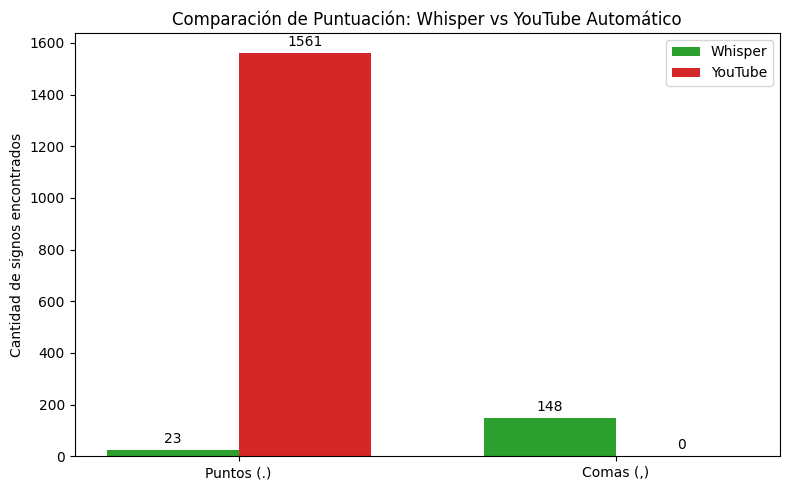

In [16]:
import matplotlib.pyplot as plt
import numpy as np

# Tomamos los datos calculados en la celda anterior
etiquetas = ['Puntos (.)', 'Comas (,)']
valores_whisper = [puntos_whisper, comas_whisper]
valores_yt = [puntos_yt, comas_yt]

x = np.arange(len(etiquetas))
ancho_barra = 0.35

# Armamos el lienzo del gráfico
fig, ax = plt.subplots(figsize=(8, 5))

# Dibujamos las barras
barra1 = ax.bar(x - ancho_barra/2, valores_whisper, ancho_barra, label='Whisper', color='#2ca02c') # Verde
barra2 = ax.bar(x + ancho_barra/2, valores_yt, ancho_barra, label='YouTube', color='#d62728')    # Rojo

ax.set_ylabel('Cantidad de signos encontrados')
ax.set_title('Comparación de Puntuación: Whisper vs YouTube Automático')
ax.set_xticks(x)
ax.set_xticklabels(etiquetas)
ax.legend()
ax.bar_label(barra1, padding=3)
ax.bar_label(barra2, padding=3)

# Mostramos el gráfico
plt.tight_layout()
plt.show()

**Conclusion**


Tras extraer y comparar ambos textos mediante código, la diferencia en la calidad de la transcripción es contundente, especialmente en la estructuración gramatical:

* **Falta de fluidez natural:** Los subtítulos de YouTube no registraron ni una sola coma (0), lo que indica que escupe las palabras como un bloque continuo sin reconocer las pausas naturales del habla. Whisper, en cambio, detectó 148 pausas lógicas.
* **Ruido en los datos:** Los 1561 "puntos" encontrados en YouTube no son finales de oración, sino "basura" proveniente de las marcas de tiempo del formato `.vtt` (ej: `00:00:08.240`). Whisper estructuró el texto correctamente con 23 puntos finales reales.

Para cualquier pipeline de Procesamiento de Lenguaje Natural, el texto generado por Whisper es mejor. Nos entrega un texto plano, limpio y estructurado en oraciones reales, listo para ser analizado. Usar el de YouTube requeriría un preprocesamiento manual enorme y tedioso para limpiar etiquetas, tiempos y adivinar dónde termina cada frase.

**Ejercicio avanzado**

Las charlas proximas a descargar son una lista de las siguientes charlas TED

Martín Reynoso - Un cerebro atento es un cerebro feliz
Kiko Martín - La confianza te cambiará la vida
Victor Küppers - Actitud
Rebeca Schürenkämper - El poder de la palabra
Guadalupe Nogués - Cómo hablar con otros que piensan distinto


In [17]:
# 1. Lista de 5 charlas TED
urls_avanzado = [
    "https://www.youtube.com/watch?v=nI_owrxLoOQ",
    "https://www.youtube.com/watch?v=KWdrwp7K_rU",
    "https://www.youtube.com/watch?v=nWecIwtN2ho",
    "https://www.youtube.com/watch?v=ECnT4yiCWso", 
    "https://www.youtube.com/watch?v=ESwDIXXyh_Y"
]

resultados_avanzado = []
errores_avanzado = []

print("INICIANDO DESCARGA POR LOTES DE 5 CHARLAS TED...")
for indice, url in enumerate(urls_avanzado, start=1):
    print(f"\nProcesando {indice}/5: {url}")
    try:
        # Usamos el modelo "base" para que tu compu lo procese más rápido
        resultado_lote = youtube_a_texto(url, modelo_whisper="base")
        resultados_avanzado.append(resultado_lote)
        print(f" OK: {resultado_lote['titulo']}")
    except Exception as error:
        errores_avanzado.append({"url": url, "error": str(error)})
        print(f"ERROR: {error}")

print(f"\nLote terminado! {len(resultados_avanzado)} exitosos, {len(errores_avanzado)} errores.")

INICIANDO DESCARGA POR LOTES DE 5 CHARLAS TED...

Procesando 1/5: https://www.youtube.com/watch?v=nI_owrxLoOQ
[youtube] Extracting URL: https://www.youtube.com/watch?v=nI_owrxLoOQ
[youtube] nI_owrxLoOQ: Downloading webpage


[youtube] nI_owrxLoOQ: Downloading android vr player API JSON
[info] nI_owrxLoOQ: Downloading 1 format(s): 251
[download] Destination: corpus\Un cerebro atento es un cerebro feliz ｜ Martín Reynoso ｜ TEDxMarDelPlata.webm
[download] 100% of   10.87MiB in 00:00:03 at 2.91MiB/s   
[ExtractAudio] Destination: corpus\Un cerebro atento es un cerebro feliz ｜ Martín Reynoso ｜ TEDxMarDelPlata.mp3
Deleting original file corpus\Un cerebro atento es un cerebro feliz ｜ Martín Reynoso ｜ TEDxMarDelPlata.webm (pass -k to keep)
Audio descargado: Un cerebro atento es un cerebro feliz | Martín Reynoso | TEDxMarDelPlata (930 segundos)
Transcripcion completa: 131 segmentos
 OK: Un cerebro atento es un cerebro feliz | Martín Reynoso | TEDxMarDelPlata

Procesando 2/5: https://www.youtube.com/watch?v=KWdrwp7K_rU
[youtube] Extracting URL: https://www.youtube.com/watch?v=KWdrwp7K_rU
[youtube] KWdrwp7K_rU: Downloading webpage


[youtube] KWdrwp7K_rU: Downloading android vr player API JSON
[info] KWdrwp7K_rU: Downloading 1 format(s): 251
[download] Destination: corpus\La confianza te cambiará la vida ｜ Kiko Martín ｜ TEDxCESINE.webm
[download] 100% of   12.81MiB in 00:00:01 at 7.61MiB/s     
[ExtractAudio] Destination: corpus\La confianza te cambiará la vida ｜ Kiko Martín ｜ TEDxCESINE.mp3
Deleting original file corpus\La confianza te cambiará la vida ｜ Kiko Martín ｜ TEDxCESINE.webm (pass -k to keep)
Audio descargado: La confianza te cambiará la vida | Kiko Martín | TEDxCESINE (1052 segundos)
Transcripcion completa: 163 segmentos
 OK: La confianza te cambiará la vida | Kiko Martín | TEDxCESINE

Procesando 3/5: https://www.youtube.com/watch?v=nWecIwtN2ho
[youtube] Extracting URL: https://www.youtube.com/watch?v=nWecIwtN2ho
[youtube] nWecIwtN2ho: Downloading webpage


[youtube] nWecIwtN2ho: Downloading android vr player API JSON
[info] nWecIwtN2ho: Downloading 1 format(s): 251
[download] Destination: corpus\Actitud ｜ Victor Küppers ｜ TEDxAndorralaVella.webm
[download] 100% of   14.64MiB in 00:00:02 at 7.13MiB/s   
[ExtractAudio] Destination: corpus\Actitud ｜ Victor Küppers ｜ TEDxAndorralaVella.mp3
Deleting original file corpus\Actitud ｜ Victor Küppers ｜ TEDxAndorralaVella.webm (pass -k to keep)
Audio descargado: Actitud | Victor Küppers | TEDxAndorralaVella (1204 segundos)
Transcripcion completa: 472 segmentos
 OK: Actitud | Victor Küppers | TEDxAndorralaVella

Procesando 4/5: https://www.youtube.com/watch?v=ECnT4yiCWso
[youtube] Extracting URL: https://www.youtube.com/watch?v=ECnT4yiCWso
[youtube] ECnT4yiCWso: Downloading webpage


[youtube] ECnT4yiCWso: Downloading android vr player API JSON
[info] ECnT4yiCWso: Downloading 1 format(s): 251
[download] Destination: corpus\El poder de la palabra  ｜ Rebeca Schürenkämper ｜ TEDxMorelia.webm
[download] 100% of    9.55MiB in 00:00:01 at 7.19MiB/s   
[ExtractAudio] Destination: corpus\El poder de la palabra  ｜ Rebeca Schürenkämper ｜ TEDxMorelia.mp3
Deleting original file corpus\El poder de la palabra  ｜ Rebeca Schürenkämper ｜ TEDxMorelia.webm (pass -k to keep)
Audio descargado: El poder de la palabra  | Rebeca Schürenkämper | TEDxMorelia (791 segundos)
Transcripcion completa: 135 segmentos
 OK: El poder de la palabra  | Rebeca Schürenkämper | TEDxMorelia

Procesando 5/5: https://www.youtube.com/watch?v=ESwDIXXyh_Y
[youtube] Extracting URL: https://www.youtube.com/watch?v=ESwDIXXyh_Y
[youtube] ESwDIXXyh_Y: Downloading webpage


[youtube] ESwDIXXyh_Y: Downloading android vr player API JSON
[info] ESwDIXXyh_Y: Downloading 1 format(s): 251
[download] Destination: corpus\Cómo hablar con otros que piensan distinto ｜ Guadalupe Nogués ｜ TEDxRiodelaPlata.webm
[download] 100% of    9.75MiB in 00:00:01 at 9.45MiB/s   
[ExtractAudio] Destination: corpus\Cómo hablar con otros que piensan distinto ｜ Guadalupe Nogués ｜ TEDxRiodelaPlata.mp3
Deleting original file corpus\Cómo hablar con otros que piensan distinto ｜ Guadalupe Nogués ｜ TEDxRiodelaPlata.webm (pass -k to keep)
Audio descargado: Cómo hablar con otros que piensan distinto | Guadalupe Nogués | TEDxRiodelaPlata (845 segundos)
Transcripcion completa: 224 segmentos
 OK: Cómo hablar con otros que piensan distinto | Guadalupe Nogués | TEDxRiodelaPlata

Lote terminado! 5 exitosos, 0 errores.


**Estadisticas descriptivas**


In [18]:
import re
from collections import Counter

texto_unido = " ".join([res["texto"] for res in resultados_avanzado]).lower()
texto_limpio = re.sub(r'[^\w\s]', '', texto_unido)
palabras = texto_limpio.split()

# Cálculos estadísticos
total_palabras = len(palabras)
promedio_palabras = total_palabras / len(resultados_avanzado) if resultados_avanzado else 0
vocabulario_unico = set(palabras) # 'set' elimina los duplicados
total_unico = len(vocabulario_unico)

# Top 20 palabras más frecuentes
conteo = Counter(palabras)
top_20 = conteo.most_common(20)

print("ESTADÍSTICAS DEL MINI-CORPUS")
print(f"Total de palabras: {total_palabras}")
print(f"Promedio por video: {promedio_palabras:.0f} palabras")
print(f"Vocabulario único (palabras distintas): {total_unico} palabras")
print("\nTop 20 palabras más frecuentes:")
for palabra, frec in top_20:
    print(f" - {palabra}: {frec} veces")

ESTADÍSTICAS DEL MINI-CORPUS
Total de palabras: 12171
Promedio por video: 2434 palabras
Vocabulario único (palabras distintas): 2391 palabras

Top 20 palabras más frecuentes:
 - que: 644 veces
 - y: 428 veces
 - de: 380 veces
 - la: 364 veces
 - a: 359 veces
 - no: 310 veces
 - es: 257 veces
 - en: 225 veces
 - lo: 214 veces
 - el: 184 veces
 - un: 136 veces
 - se: 127 veces
 - una: 119 veces
 - pero: 114 veces
 - los: 104 veces
 - porque: 97 veces
 - las: 96 veces
 - con: 94 veces
 - por: 94 veces
 - me: 87 veces


*Visualizacion*

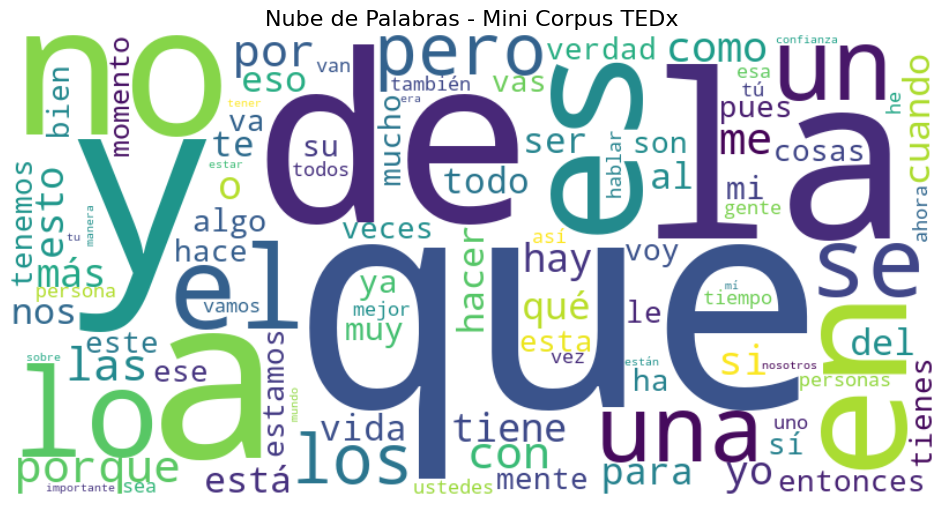

In [20]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud

nube = WordCloud(
    width=800, 
    height=400, 
    background_color='white',
    colormap='viridis', 
    max_words=100 
)

nube.generate_from_frequencies(conteo)

plt.figure(figsize=(12, 6))
plt.imshow(nube, interpolation='bilinear')
plt.axis('off') # Le sacamos los bordes y números
plt.title('Nube de Palabras - Mini Corpus TEDx', fontsize=16)
plt.show()

**Reflexion final**


Al analizar las estadísticas descriptivas, noto que aunque Whisper nos entrega un texto limpio de marcas de tiempo, **no es inmediatamente adecuado** para ajustar un modelo de lenguaje avanzado o hacer un análisis lingüístico profundo sin aplicar un trabajo extra. 

**¿Por qué?**
Al ver las 20 palabras más frecuentes, predominan absolutamente las "Stopwords" (artículos y preposiciones como "que", "de", "la", "el"). Estas palabras aportan estructura gramatical pero no tienen ningún significado semántico real sobre el tema central de las charlas TED. Además, al ser un registro oral natural, abundan las muletillas, repeticiones o frases inconclusas propias del habla.

**Preprocesamiento adicional necesario:**
Para que este corpus sea verdaderamente útil en PLN, deberíamos aplicarle:
1. **Eliminación de Stopwords:** Filtrar las palabras vacías (artículos, preposiciones, conectores) para que nuestro vocabulario único y el conteo de frecuencias reflejen los verdaderos conceptos (sustantivos, verbos y adjetivos clave).
2. **Lematización:** Llevar las palabras a su raíz (por ejemplo, transformar "dijo", "diría", "dice" al verbo base "decir") para no contar la misma palabra como si fueran conceptos distintos en el vocabulario único.
3. **Limpieza de marcas de oralidad:** Detectar y remover muletillas (ej: "eh", "mmm", "o sea") que ensucian el análisis.

## Que sigue?

Ya tenes texto extraido de la web y ahora tambien texto obtenido desde fuentes audiovisuales. Eso cerro el bloque de adquisición de corpus. El texto transcripto, sin embargo, presenta rasgos particulares: puntuacion menos estable, hesitaciones, repeticiones, cortes y marcas de oralidad que no siempre aparecen en el texto escrito. Por eso resulta especialmente interesante para el procesamiento linguistico. En la proxima clase vamos a tomar tanto texto scrapeado como texto transcripto y lo vamos a procesar con `spaCy`, para comparar como se comporta el pipeline sobre distintos tipos de fuente.


## Recursos y referencias

- `yt-dlp`: https://github.com/yt-dlp/yt-dlp
- Radford, A. et al. (2022). *Robust Speech Recognition via Large-Scale Weak Supervision.* OpenAI.
- `faster-whisper`: https://github.com/SYSTRAN/faster-whisper
- `whisperX`: https://github.com/m-bain/whisperX
- Bender, E. M. et al. (2021). *On the Dangers of Stochastic Parrots.* Ver especialmente la discusion sobre datos, sesgos y condiciones de produccion.
